<a href="https://colab.research.google.com/github/anvithagangineni/portfolio/blob/main/heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#This Machine Learning program helps predict whether a patient is at risk of heart disease based on their medical features. It compares the accuracy of a Decision Tree classifier and a Random Forest model to show how well ensemble methods improve model performance.

In [1]:
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report, f1_score, jaccard_score, recall_score, ConfusionMatrixDisplay

In [2]:
drive.mount('/content/drive')
dataset=pd.read_csv('/content/drive/MyDrive/datasets/htd (1).csv')
dataset

Mounted at /content/drive


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
X=dataset[['age','sex',	'cp',	'trestbps',	'chol',	'fbs',	'restecg',	'thalach',	'exang',	'oldpeak',	'slope',	'ca',	'thal']]
y=dataset['target']

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [6]:
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Jaccard Score:", jaccard_score(y_test, y_pred))
print("Recall Score:", recall_score(y_test, y_pred))

Accuracy: 0.73
F1 Score: 0.7476635514018691
Jaccard Score: 0.5970149253731343
Recall Score: 0.6896551724137931


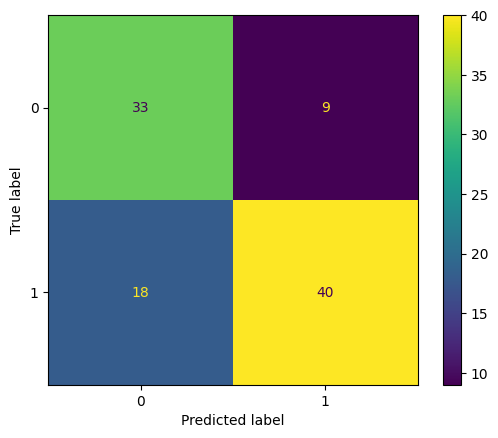

In [7]:
ConfusionMatrixDisplay.from_estimator(clf,X_test,y_test)

In [9]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.79      0.71        42
           1       0.82      0.69      0.75        58

    accuracy                           0.73       100
   macro avg       0.73      0.74      0.73       100
weighted avg       0.75      0.73      0.73       100



In [10]:
params = {
    'criterion': ["gini", "entropy"],
    'splitter': ['best', 'random'],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [2, 4, 5],
    'min_samples_split': [2, 3],
    'max_depth': [1, 2, 3, None]
}

In [11]:
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params, scoring='accuracy', cv=5)
grid.fit(X, y)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [2, 4, 5],
                         'min_samples_split': [2, 3],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [12]:
print("\nBest Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'random'}
Best CV Score: 0.7590710382513661


In [16]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [17]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest F1:", f1_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print("Random Forest Jaccard:", jaccard_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.84
Random Forest F1: 0.8596491228070176
Random Forest Recall: 0.8448275862068966
Random Forest Jaccard: 0.7538461538461538
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        42
           1       0.88      0.84      0.86        58

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", scores)
print("Mean Accuracy:", scores.mean())


Cross-Validation Accuracy Scores: [0.81967213 0.8852459  0.83606557 0.85       0.8       ]
Mean Accuracy: 0.8381967213114756
